# Retail Sales Data Analysis using Python

## Overview

This project analyzes a retail transactions dataset to identify sales trends, customer purchasing behavior, product performance, and revenue insights using Python.

## Objectives

- Clean and prepare raw retail transaction data
- Perform exploratory data analysis (EDA)
- Identify top-selling products
- Analyze monthly sales trends
- Explore customer purchasing patterns
- Generate business insights through visualizations

## Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib

## Dataset

Online Retail II Dataset containing one year of transactional retail sales data.

---

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
DATASET_PATH = "online_retail_II.xlsx"

df_original = pd.read_excel(DATASET_PATH)

In [4]:
df = df_original.copy()
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


## DATA EXPLORATION

In [5]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

In [6]:
# the time period to which this data belongs:

df['InvoiceDate'].min(), df['InvoiceDate'].max()

(Timestamp('2009-12-01 07:45:00'), Timestamp('2010-12-09 20:01:00'))

In [7]:
# checking the basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [8]:
# This will show you exactly how many nulls exist in every column
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [9]:
# we found null entries in the columns Customer ID and Description. 
# treating the null values: 
# we will not drop the null values in the Customer ID column as it would be a loss of data. Instead, we will replace the null values with a placeholder value.
df['Customer ID']=df['Customer ID'].fillna('Guest')

In [10]:
# treating the product description columns:
# the first thing which comes to mind since description is a categorical feature is to fill the null values with the mode of the column.  
# but 2928 missing entries imputed with the mode will give us wrong analytics/description since this is a product oriented data

df['Description'].value_counts()


Description
WHITE HANGING HEART T-LIGHT HOLDER    3549
REGENCY CAKESTAND 3 TIER              2212
STRAWBERRY CERAMIC TRINKET BOX        1843
PACK OF 72 RETRO SPOT CAKE CASES      1466
ASSORTED COLOUR BIRD ORNAMENT         1457
                                      ... 
GLASS BELL JAR LARGE                     1
SILICON CUBE 25W, BLUE                   1
BAKING MOULD EASTER EGG MILK CHOC        1
*Boombox Ipod Classic                    1
faulty                                   1
Name: count, Length: 4681, dtype: int64

In [11]:
# if we impute the null entries in the Description column with the mode which in this case would be 'WHITE HANGING HEART T-LIGHT HOLDER' which will
# make the data extremely biased in nature. This does not make sense. Imputing with the mode would be a wrong approach for this data.

# fetching all the NAN product description data

null_description = df[df['Description'].isnull()==True]
null_description 


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,Guest,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,Guest,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,Guest,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,Guest,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,Guest,United Kingdom
...,...,...,...,...,...,...,...,...
524730,538141,22218,NaN,2,2010-12-09 15:58:00,0.0,Guest,United Kingdom
524731,538143,84534B,NaN,1,2010-12-09 15:58:00,0.0,Guest,United Kingdom
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.0,Guest,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.0,Guest,United Kingdom


In [12]:
null_description['Customer ID'].nunique()

1

In [13]:
# all the customers with unknown product description are 'Guest'. - unknown customer
# Price is also zero for all these entries 
# even if we consider zero price for the negative entries which might be returns, the price is still zero for all the positive entries as well. This is a major finding.
# These rows are vague, helpless, garbage data. We will try to see if these can be useful in any way by trying to see if they 
# can be mapped to the corresponding StockCodes..

In [14]:
x=df[df['StockCode']==21646]
x
# single entry for this stock code. 

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,Guest,United Kingdom


In [15]:
y=df[df['StockCode']==20683]
y
# we can possibly map this stock code to the description available 'RAIN GIRL CHILDS UMBRELLA'

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,Guest,United Kingdom
24774,491435,20683,RAIN GIRL CHILDS UMBRELLA,1,2009-12-11 10:10:00,3.25,14606.0,United Kingdom
43854,493252,20683,NaN,1,2009-12-22 13:51:00,0.00,Guest,United Kingdom


In [16]:
z=df[df['StockCode']=='84534B']
z
# 192 entries of this stock code. We can map this stock code to the description available 'FAIRY CAKE NOTEBOOK A5 SIZE'

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1862,489594,84534B,FAIRY CAKE NOTEBOOK A5 SIZE,4,2009-12-01 14:19:00,0.85,15005.0,United Kingdom
5007,489856,84534B,FAIRY CAKE NOTEBOOK A5 SIZE,1,2009-12-02 14:36:00,1.70,Guest,United Kingdom
5564,489857,84534B,FAIRY CAKE NOTEBOOK A5 SIZE,1,2009-12-02 14:43:00,1.70,Guest,United Kingdom
8247,490074,84534B,FAIRY CAKE NOTEBOOK A5 SIZE,1,2009-12-03 14:39:00,1.70,Guest,United Kingdom
9853,490149,84534B,FAIRY CAKE NOTEBOOK A5 SIZE,4,2009-12-04 09:43:00,1.70,Guest,United Kingdom
...,...,...,...,...,...,...,...,...
514090,537240,84534B,FAIRY CAKE NOTEBOOK A5 SIZE,1,2010-12-06 10:08:00,1.66,Guest,United Kingdom
516766,537434,84534B,FAIRY CAKE NOTEBOOK A5 SIZE,2,2010-12-06 16:57:00,1.66,Guest,United Kingdom
518499,537638,84534B,FAIRY CAKE NOTEBOOK A5 SIZE,1,2010-12-07 15:28:00,1.66,Guest,United Kingdom
523340,538048,84534B,FAIRY CAKE NOTEBOOK A5 SIZE,16,2010-12-09 13:14:00,0.85,15945.0,United Kingdom


In [17]:
k=df[df['StockCode']==20892]
k
# Set/3 TALL GLASS CANDER HOLDER PINK is the description for this stock code, so this can be mapped as well

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
337,489514,20892,SET/3 TALL GLASS CANDLE HOLDER PINK,8,2009-12-01 11:21:00,3.95,15311.0,United Kingdom
399,C489518,20892,SET/3 TALL GLASS CANDLE HOLDER PINK,-2,2009-12-01 11:35:00,12.75,15461.0,United Kingdom
709,489532,20892,SET/3 TALL GLASS CANDLE HOLDER PINK,2,2009-12-01 11:58:00,12.75,13394.0,United Kingdom
19503,C490995,20892,SET/3 TALL GLASS CANDLE HOLDER PINK,-6,2009-12-08 17:16:00,12.75,18252.0,United Kingdom
26809,491672,20892,SET/3 TALL GLASS CANDLE HOLDER PINK,8,2009-12-13 11:46:00,3.95,17172.0,United Kingdom
31111,491969,20892,SET/3 TALL GLASS CANDLE HOLDER PINK,1,2009-12-14 17:57:00,26.04,Guest,United Kingdom
39072,C492679,20892,SET/3 TALL GLASS CANDLE HOLDER PINK,-2,2009-12-17 18:20:00,12.75,13394.0,United Kingdom
39836,492745,20892,SET/3 TALL GLASS CANDLE HOLDER PINK,8,2009-12-18 12:59:00,3.95,16600.0,United Kingdom
40380,492778,20892,SET/3 TALL GLASS CANDLE HOLDER PINK,8,2009-12-18 16:13:00,3.95,18252.0,United Kingdom
41391,492794,20892,SET/3 TALL GLASS CANDLE HOLDER PINK,2,2009-12-20 10:41:00,12.75,13847.0,United Kingdom


In [18]:
n=df[df['StockCode']==22423]
n

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
124243,501276,22423,REGENCY CAKESTAND 3 TIER,8,2010-03-15 13:55:00,12.75,18135.0,United Kingdom
125330,501320,22423,REGENCY CAKESTAND 3 TIER,8,2010-03-16 09:49:00,12.75,15123.0,United Kingdom
125379,501345,22423,REGENCY CAKESTAND 3 TIER,8,2010-03-16 10:49:00,12.75,15946.0,United Kingdom
125560,501422,22423,REGENCY CAKESTAND 3 TIER,1,2010-03-16 11:53:00,12.75,14146.0,United Kingdom
125771,501434,22423,REGENCY CAKESTAND 3 TIER,1,2010-03-16 13:15:00,12.75,14496.0,United Kingdom
...,...,...,...,...,...,...,...,...
524745,538145,22423,REGENCY CAKESTAND 3 TIER,2,2010-12-09 16:08:00,12.75,15211.0,United Kingdom
524836,538148,22423,REGENCY CAKESTAND 3 TIER,3,2010-12-09 16:26:00,25.49,Guest,United Kingdom
524951,538149,22423,REGENCY CAKESTAND 3 TIER,3,2010-12-09 16:27:00,25.49,Guest,United Kingdom
525068,538153,22423,REGENCY CAKESTAND 3 TIER,2,2010-12-09 16:31:00,25.49,Guest,United Kingdom


In [19]:
# I would like to check if this similar stock code belongs to some other product description as well since
# this is a long list of 2221 rows and I cannot see all of them properly. 
# I will check if there are any other product descriptions for this stock code.
n[n['Description']!='REGENCY CAKESTAND 3 TIER']

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
192773,507688,22423,smashed,-32,2010-05-11 09:56:00,0.0,Guest,United Kingdom
193100,507708,22423,damaged,-90,2010-05-11 11:18:00,0.0,Guest,United Kingdom
213344,510068,22423,NaN,-30,2010-05-27 11:08:00,0.0,Guest,United Kingdom
256099,514102,22423,damaged,-14,2010-06-30 12:32:00,0.0,Guest,United Kingdom
276229,516200,22423,smashed,-31,2010-07-19 10:33:00,0.0,Guest,United Kingdom
374144,525460,22423,"broken, uneven bottom",-35,2010-10-05 14:46:00,0.0,Guest,United Kingdom
416038,529134,22423,wonky bottom/broken,-35,2010-10-26 14:48:00,0.0,Guest,United Kingdom
472121,533872,22423,damaged,-29,2010-11-19 11:35:00,0.0,Guest,United Kingdom
524286,538072,22423,faulty,-13,2010-12-09 14:10:00,0.0,Guest,United Kingdom


In [20]:
# we can see that one StockCode can have multiple product descriptions. This is a major finding. 
# In this case, mapping will not be a wise choice 
# we cannot pick up all the 2982 products and fill it with product descriptions when some of them are having more than one description for a similar stock code.
# This will be a very tedious task and will not be feasible.
# justification: missing customer ID (guest), missing product description, zero price for all the entries, and multiple product descriptions for a single stock code.
# we choose to drop the rows with null product descriptions as we have enough evidence to prove that these rows are not useful for our analysis, garbage entries. 
# from 525461 entries, losing 2928 entries will not be a big loss since there are still 522533 entries left which is a huge number of entries to work with.
df=df.dropna()
# we could use subset Description to drop the rows with null values in the Description column 
# but we have already filled the null values in the Customer ID column with 'Guest' so we will not use subset here.
# simple dropna() will work here since we have already filled the null values in the Customer ID column with 'Guest'

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 522533 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      522533 non-null  object        
 1   StockCode    522533 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     522533 non-null  int64         
 4   InvoiceDate  522533 non-null  datetime64[us]
 5   Price        522533 non-null  float64       
 6   Customer ID  522533 non-null  object        
 7   Country      522533 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(4), str(1)
memory usage: 35.9+ MB


In [22]:
# While going through the above processes, I got to know that the StockCode columns has alphanumeric as well as numeric values, 
# but the alphanumeric values are treated as string and numeric values are treated as integers. This is a major issue
# we will make sure the stock code column is treated as string so that we can map the stock codes to the product descriptions properly.

df['StockCode'] = df['StockCode'].astype(str)

In [23]:
# count of different stock codes in the data
df['StockCode'].value_counts()

StockCode
85123A    3516
22423     2220
85099B    2057
21212     1933
21232     1843
          ... 
85049g       1
72803b       1
79151B       1
22933        1
21120        1
Name: count, Length: 4276, dtype: int64

In [24]:
df['Description'].value_counts() # count of various product descriptions in the data

Description
WHITE HANGING HEART T-LIGHT HOLDER    3549
REGENCY CAKESTAND 3 TIER              2212
STRAWBERRY CERAMIC TRINKET BOX        1843
PACK OF 72 RETRO SPOT CAKE CASES      1466
ASSORTED COLOUR BIRD ORNAMENT         1457
                                      ... 
GLASS BELL JAR LARGE                     1
SILICON CUBE 25W, BLUE                   1
BAKING MOULD EASTER EGG MILK CHOC        1
*Boombox Ipod Classic                    1
faulty                                   1
Name: count, Length: 4681, dtype: int64

In [25]:
# lets see if StockCode 85123A and Description 'WHITE HANGING HEART T-LIGHT HOLDER' are related to each other or not
# since they are the most frequent stock code and product description in the data respectively.
df[(df['StockCode'] == '85123A')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
102,489442,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2009-12-01 09:46:00,2.95,13635.0,United Kingdom
147,489446,85123A,WHITE HANGING HEART T-LIGHT HOLDER,32,2009-12-01 10:06:00,2.55,13758.0,United Kingdom
271,489465,85123A,WHITE HANGING HEART T-LIGHT HOLDER,64,2009-12-01 10:52:00,2.55,13767.0,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,Guest,United Kingdom
366,489517,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1,2009-12-01 11:34:00,2.95,16329.0,United Kingdom
...,...,...,...,...,...,...,...,...
524412,538086,85123A,WHITE HANGING HEART T-LIGHT HOLDER,14,2010-12-09 14:44:00,2.95,12872.0,United Kingdom
524519,538095,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1,2010-12-09 14:55:00,2.95,17097.0,Spain
524733,538145,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-09 16:08:00,2.95,15211.0,United Kingdom
525223,538157,85123A,WHITE HANGING HEART T-LIGHT HOLDER,4,2010-12-09 16:57:00,2.95,17576.0,United Kingdom


In [26]:
# it is right, the 'WHITE HANGING HEART T-LIGHT HOLDER' is the product description for the stock code 85123A, 
# but we also see some other product descriptions for the same stock code such as one in no. 284 (21733 mixed). This is the reason 
# The value count of the StockCode 85123A does not match with the product description 'WHITE HANGING HEART T-LIGHT HOLDER'.

In [27]:
df['Country'].value_counts() 
# brief understanding of countries in the data. We can see that the data is mostly from the United Kingdom.
# we have 310 unspecified country as well

Country
United Kingdom          482924
EIRE                      9670
Germany                   8129
France                    5772
Netherlands               2769
Spain                     1278
Switzerland               1187
Portugal                  1101
Belgium                   1054
Channel Islands            906
Sweden                     902
Italy                      731
Australia                  654
Cyprus                     554
Austria                    537
Greece                     517
United Arab Emirates       432
Denmark                    428
Norway                     369
Finland                    354
Unspecified                310
USA                        244
Japan                      224
Poland                     194
Malta                      172
Lithuania                  154
Singapore                  117
RSA                        111
Bahrain                    107
Canada                      77
Hong Kong                   76
Thailand                    76


In [28]:
df['Country'].nunique() # this shows we have 40 different countries - 39 actual countries and 1 unspecified country.

40

In [29]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [ ]:
# creating a new column for overall price of the product purchased by the customer.
df['Overall_price'] = (abs(df['Quantity'])) * df['Price']
# we used abs() function to get the absolute value of the quantity since we are calculating the overall price of the product returned or purchased by the customer, which 
# will be negative if we don't use abs().

In [ ]:
df[df['Quantity'] < 0] # this shows all the negative quantity entries in the data. These are the returned products by the customers. 
#The overall price will still be positive since we are charging money for the product returned by the customer.

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Overall_price
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,35.40
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,9.90
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,17.00
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,12.60
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,35.40
...,...,...,...,...,...,...,...,...,...
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.0,United Kingdom,2.95
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.0,United Kingdom,12.75
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.00,Guest,United Kingdom,0.00
525235,538162,46000M,Dotcom sales,-100,2010-12-09 17:25:00,0.00,Guest,United Kingdom,0.00


In [39]:
df[df['Quantity'] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Overall_price
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,35.40
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,9.90
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,17.00
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,12.60
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,35.40
...,...,...,...,...,...,...,...,...,...
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.0,United Kingdom,2.95
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.0,United Kingdom,12.75
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.00,Guest,United Kingdom,0.00
525235,538162,46000M,Dotcom sales,-100,2010-12-09 17:25:00,0.00,Guest,United Kingdom,0.00


In [41]:
int(df.duplicated().sum()) # this shows the number of duplicate entries in the data. We have 6865 duplicate entries in the data.

6865

In [43]:
df = df.drop_duplicates() # dropping the duplicate entries in the data. We have 515668 entries left after dropping the duplicate entries.
df.shape

(515668, 9)

In [47]:
# checking the statistics of data
df.describe()

,Quantity,InvoiceDate,Price,Overall_price
count,515668.000000,515668,515668.000000,515668.000000
mean,10.617719,2010-06-28 11:56:09.179161,4.742955,20.876597
min,-9360.000000,2009-12-01 07:45:00,-53594.360000,-53594.360000
25%,1.000000,2010-03-21 13:27:00,1.250000,4.200000
50%,3.000000,2010-07-06 09:58:30,2.100000,10.200000
75%,10.000000,2010-10-15 12:20:00,4.210000,17.700000
max,19152.000000,2010-12-09 20:01:00,25111.090000,25111.090000
std,98.548503,NaN,147.507035,161.535041


In [ ]:
# we cannot check the correlation for Invoice Date since it is a datetime object. 
# checking the correlation for the numeric columns in the data
df.corr(numeric_only=True)
# quantity and price/overall price have no correlation
# price and overall price have a strong correlation since overall price is calculated using price and quantity, but not exactly 1 since some of the quantities are negative
# there are no duplicate columns since the correlation is not exactly 1 or -1 for any columns. no need to drop any columns. 

,Quantity,Price,Overall_price
Quantity,1.000000,-0.002196,0.150073
Price,-0.002196,1.000000,0.912544
Overall_price,0.150073,0.912544,1.000000


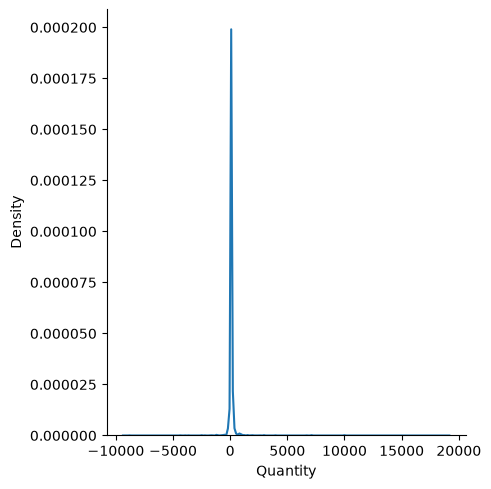

In [ ]:
sns.displot(df['Quantity'],kind='kde') # the graph shows that the data (quantity column) is not normally distributed. 
# there is skewness in both the directions but more towards the right side

In [52]:
# checking outliers for quantity
q1 = df['Quantity'].quantile(0.25)
q3 = df['Quantity'].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = df.loc[(df['Quantity'] < lower_fence) | (df['Quantity'] > upper_fence)]
outliers # more than half a lakh of entries are outliers

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Overall_price
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.60
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
10,489435,22195,HEART MEASURING SPOONS LARGE,24,2009-12-01 07:46:00,1.65,13085.0,United Kingdom,39.60
...,...,...,...,...,...,...,...,...,...
525283,538165,22988,SOLDIERS EGG CUP,72,2010-12-09 17:34:00,1.25,14031.0,United Kingdom,90.00
525285,538165,37370,RETRO COFFEE MUGS ASSORTED,72,2010-12-09 17:34:00,1.06,14031.0,United Kingdom,76.32
525303,538167,22086,PAPER CHAIN KIT 50'S CHRISTMAS,40,2010-12-09 18:58:00,2.55,14713.0,United Kingdom,102.00
525335,538168,22952,60 CAKE CASES VINTAGE CHRISTMAS,24,2010-12-09 19:23:00,0.55,14702.0,United Kingdom,13.20


In [51]:
print (f"Lower fence: {lower_fence}, Upper fence: {upper_fence}")

Lower fence: -12.5, Upper fence: 23.5


In [ ]:
df[df['Quantity']<lower_fence] #capping the lower fence value for these outliers will be applicable, lets check the upper fence outliers as well

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Overall_price
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia,20.40
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,Guest,United Kingdom,0.00
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,Guest,United Kingdom,0.00
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,Guest,United Kingdom,0.00
1353,C489563,90088,CRYSTAL KEY+LOCK PHONE CHARM,-24,2009-12-01 13:09:00,0.85,13526.0,United Kingdom,20.40
...,...,...,...,...,...,...,...,...,...
524457,538090,20956,?,-723,2010-12-09 14:48:00,0.00,Guest,United Kingdom,0.00
524637,C538110,21232,STRAWBERRY CERAMIC TRINKET BOX,-144,2010-12-09 15:24:00,1.06,17307.0,United Kingdom,152.64
524638,C538111,21830,ASSORTED CREEPY CRAWLIES,-24,2010-12-09 15:24:00,0.42,17950.0,United Kingdom,10.08
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.00,Guest,United Kingdom,0.00


In [ ]:
df[df['Quantity']>upper_fence] #capping the upper fence value for these many outliers will really affect the data and analysis

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Overall_price
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.60
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
10,489435,22195,HEART MEASURING SPOONS LARGE,24,2009-12-01 07:46:00,1.65,13085.0,United Kingdom,39.60
...,...,...,...,...,...,...,...,...,...
525283,538165,22988,SOLDIERS EGG CUP,72,2010-12-09 17:34:00,1.25,14031.0,United Kingdom,90.00
525285,538165,37370,RETRO COFFEE MUGS ASSORTED,72,2010-12-09 17:34:00,1.06,14031.0,United Kingdom,76.32
525303,538167,22086,PAPER CHAIN KIT 50'S CHRISTMAS,40,2010-12-09 18:58:00,2.55,14713.0,United Kingdom,102.00
525335,538168,22952,60 CAKE CASES VINTAGE CHRISTMAS,24,2010-12-09 19:23:00,0.55,14702.0,United Kingdom,13.20


In [ ]:
# we will consider increasing the q3 from 0.75 to 0.95 to accommodate more data and reduce the number 
# of outliers. This will help us in better analysis and insights from the data.

q3 = df['Quantity'].quantile(0.95)
upper_fence = q3 + 1.5 * iqr
df[df['Quantity']>upper_fence]

# 19362 rows is still a huge number of outliers but we will have to work with this since capping the upper fence value 
# for these many outliers will really affect the data and analysis.

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Overall_price
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
58,489438,20711,JUMBO BAG TOYS,60,2009-12-01 09:24:00,1.30,18102.0,United Kingdom,78.00
61,489438,84031A,CHARLIE+LOLA RED HOT WATER BOTTLE,56,2009-12-01 09:24:00,3.00,18102.0,United Kingdom,168.00
62,489438,84031B,CHARLIE LOLA BLUE HOT WATER BOTTLE,56,2009-12-01 09:24:00,3.00,18102.0,United Kingdom,168.00
63,489438,84032A,CHARLIE+LOLA PINK HOT WATER BOTTLE,60,2009-12-01 09:24:00,1.90,18102.0,United Kingdom,114.00
...,...,...,...,...,...,...,...,...,...
524690,538120,22198,LARGE POPCORN HOLDER,50,2010-12-09 15:35:00,1.45,17017.0,United Kingdom,72.50
525005,538151,47566,PARTY BUNTING,50,2010-12-09 16:28:00,3.75,16163.0,United Kingdom,187.50
525283,538165,22988,SOLDIERS EGG CUP,72,2010-12-09 17:34:00,1.25,14031.0,United Kingdom,90.00
525285,538165,37370,RETRO COFFEE MUGS ASSORTED,72,2010-12-09 17:34:00,1.06,14031.0,United Kingdom,76.32


In [61]:
# treating the outliers for quantity column

df['Quantity']=df['Quantity'].apply(lambda x:lower_fence if x<lower_fence else x)
df['Quantity']=df['Quantity'].apply(lambda x:upper_fence if x>upper_fence else x)

In [62]:
df[df['Quantity']>upper_fence]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Overall_price


In [63]:
df[df['Quantity']<lower_fence]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Overall_price


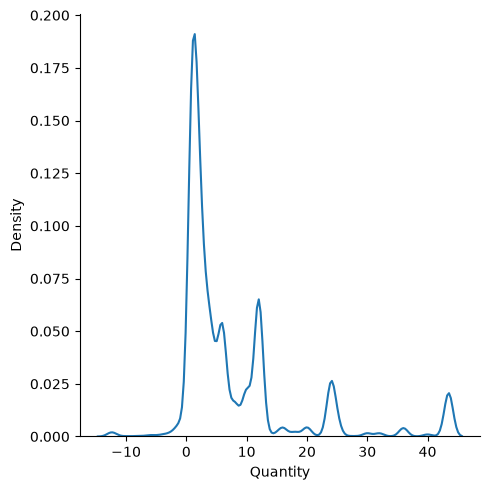

In [ ]:
sns.displot(df['Quantity'],kind='kde') # the kde plot shows that the data is still not normally distributed but the skewness has reduced a bit. 
# The data is still skewed towards the right side, but the distribution looks much better than before. 
# We will have to work with this data since we cannot remove the outliers as it will affect the data and analysis.

### Plotting top 5 stocks:

In [ ]:
# we are going to consider product description column for this instead of StockCode as we know that one stockcode does have multiple product descriptions 

qty_stock=df.groupby('Description').agg({'Quantity':'sum'})
qty_stock=qty_stock.reset_index()
qty_stock=qty_stock.sort_values(by='Quantity',ascending=False)[:5]
qty_stock

,Description,Quantity
4402,WHITE HANGING HEART T-LIGHT HOLDER,41639.0
2744,PACK OF 72 RETRO SPOT CAKE CASES,27379.0
279,ASSORTED COLOUR BIRD ORNAMENT,24989.5
147,60 TEATIME FAIRY CAKE CASES,22420.0
4067,STRAWBERRY CERAMIC TRINKET BOX,20570.0


In [ ]:
qty_stock = df.groupby('Description')['Quantity'].sum().nlargest(5).reset_index() #another way to do it
qty_stock

,Description,Quantity
0,WHITE HANGING HEART T-LIGHT HOLDER,41639.0
1,PACK OF 72 RETRO SPOT CAKE CASES,27379.0
2,ASSORTED COLOUR BIRD ORNAMENT,24989.5
3,60 TEATIME FAIRY CAKE CASES,22420.0
4,STRAWBERRY CERAMIC TRINKET BOX,20570.0


C:\Users\Aniket\AppData\Local\Temp\ipykernel_19000\2090976039.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=qty_stock,x='Quantity',y='Description',palette='bright')


<Axes: xlabel='Quantity', ylabel='Description'>

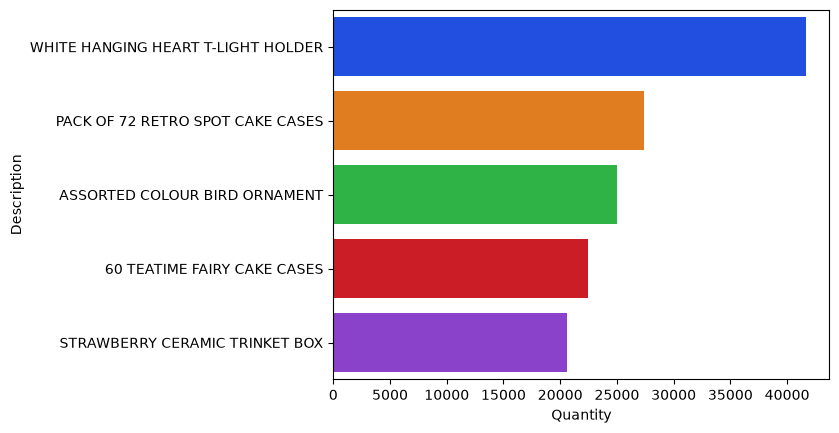

In [74]:
#plotting the graph
sns.barplot(data=qty_stock,x='Quantity',y='Description',palette='bright')

### Country wise sales:

In [80]:
sales=df.groupby('Country').agg({'Overall_price':'sum'})
sales=sales.reset_index()
sales

,Country,Overall_price
0,Australia,32841.800
1,Austria,13805.380
2,Bahrain,2398.150
3,Belgium,26431.130
4,Bermuda,1253.140
5,Brazil,268.270
6,Canada,1216.660
7,Channel Islands,27725.320
8,Cyprus,11520.400
9,Denmark,54840.750


C:\Users\Aniket\AppData\Local\Temp\ipykernel_19000\554291791.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales,x='Overall_price',y='Country',palette='bright')


<Axes: xlabel='Overall_price', ylabel='Country'>

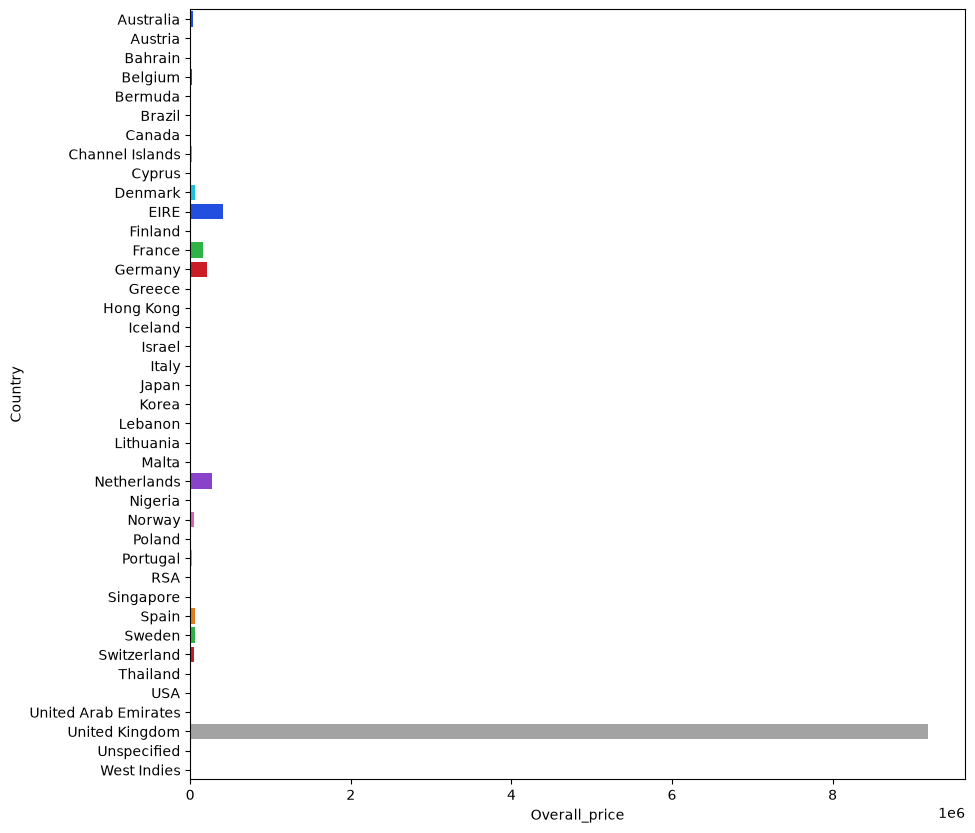

In [ ]:
plt.figure(figsize=(10,10))
sns.barplot(data=sales,x='Overall_price',y='Country',palette='bright') #united kingdom with the highest sales

### Common purchase pattern by country and month:

In [82]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Overall_price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",43.5,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2.0,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1.0,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1.0,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2.0,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50


In [85]:
# extracting month from datetime column
df['Month']=df['InvoiceDate'].dt.month

In [88]:
#applying groupby to identify monthly patterns
monthly_sales=df.groupby(['Country','Month']).agg({'Overall_price':'sum'}).unstack().fillna(0)
monthly_sales=monthly_sales.reset_index()
monthly_sales

Country Overall_price                                      \
Month                                   1           2           3           4   
0                 Australia         0.000    1029.660     429.390     630.950   
1                   Austria         0.000    1118.860     925.130    1388.540   
2                   Bahrain         0.000     439.850     591.300       0.000   
3                   Belgium      1643.970    4717.650     884.520    2591.640   
4                   Bermuda         0.000       0.000    1253.140       0.000   
5                    Brazil         0.000       0.000       0.000       0.000   
6                    Canada         0.000       0.000       0.000       0.000   
7           Channel Islands       854.650       0.000    1999.780     926.820   
8                    Cyprus        76.520     750.490    2904.790    1167.500   
9                   Denmark      7870.600   23440.700    7595.180     748.000   
10                     EIRE     70753.560   22568.350   24113.140   24515.210   
11                  Finland       944.070       0.000       0.000    1255.130   
12                   France      8582.250    9067.310    8864.160    7683.050   
13                  Germany     13223.010    9377.250   17037.330   23865.971   
14                   Greece      4798.350       0.000     555.180     277.930   
15                Hong Kong         0.000       0.000       0.000    2236.610   
16                  Iceland         0.000       0.000       0.000       0.000   
17                   Israel         0.000       0.000       0.000       0.000   
18                    Italy        39.670       0.000     734.220    2186.710   
19                    Japan         2.950     230.730     220.800       2.750   
20                    Korea         0.000       0.000       0.000       0.000   
21                  Lebanon         0.000       0.000       0.000       0.000   
22                Lithuania         0.000       0.000       0.000       0.000   
23                    Malta         0.000    2454.570       0.000       0.000   
24              Netherlands     29249.150   18563.470   24936.340    6888.780   
25                  Nigeria        27.820       0.000       0.000       0.000   
26                   Norway         0.000       0.000   33628.550       0.000   
27                   Poland         0.000       0.000     318.860       0.000   
28                 Portugal       130.850     458.830    2557.300     209.780   
29                      RSA         0.000     931.430       0.000       0.000   
30                Singapore         0.000       0.000       0.000    1252.950   
31                    Spain      5616.830     643.040    1688.470     892.480   
32                   Sweden      1720.150    8202.580    1725.580   19420.800   
33              Switzerland         0.000     477.680     951.620    1976.760   
34                 Thailand         0.000       0.000       0.000       0.000   
35                      USA      2289.590       0.000       0.000       0.000   
36     United Arab Emirates         0.000    3840.000    1201.520      16.500   
37           United Kingdom    530934.882  464178.776  763466.981  562247.711   
38              Unspecified      1071.850       0.000       0.000     252.520   
39              West Indies         0.000       0.000       0.000       0.000   

                                                                           \
Month          5          6          7          8           9          10   
0        3429.60    3240.28     738.62     176.00     785.830     2989.15   
1         662.04     268.10       0.00    1043.15    2291.220     1236.70   
2         585.96     463.28       0.00       0.00       0.000      317.76   
3         111.35    4065.29    1914.23    1713.62    1191.760     1475.72   
4           0.00       0.00       0.00       0.00       0.000        0.00   
5           0.00       0.00       0.00       0.00     268.270        0.00   
6

<Axes: title={'center': 'Monthly Sales by Country'}, xlabel='None,Month', ylabel='Sales'>

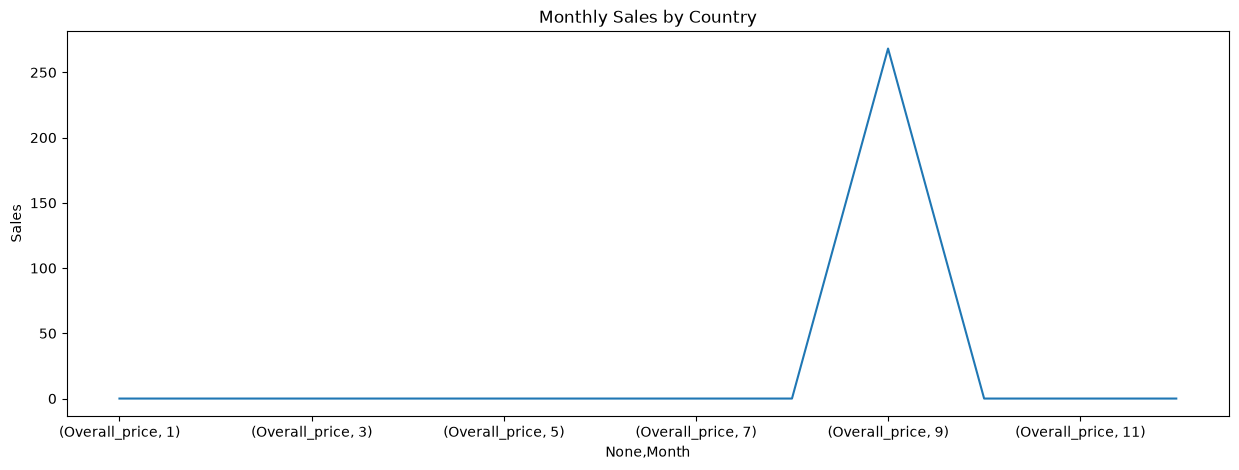

In [ ]:
# using matplotlib
plt.figure(figsize=(15,5))
monthly_sales_T=monthly_sales.set_index('Country').T
plt.title('Monthly Sales by Country')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
monthly_sales_T['Brazil'].plot(kind='line')

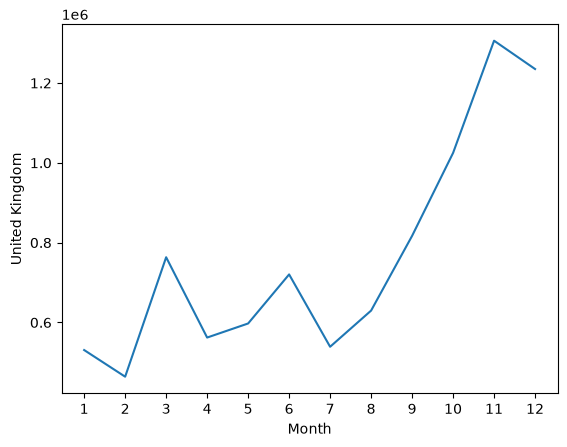

In [ ]:
# using seaborn
sns.lineplot(data=monthly_sales_T,x='Month',y='United Kingdom')
plt.xticks(range(1,13))
plt.show()

### Function to analyze the product sale:

In [94]:
# creating a function to analyze sales performance of specific product (Total sales, quantity sold etc) across all the countries:

def analyze_product(prod_des,data):
    prod_des=data[data['Description']==prod_des] #filtering the data for product
    total_sales=int(prod_des['Overall_price'].sum()) #calculating total sales
    total_quantity=int(prod_des['Quantity'].sum()) #calculating total quantity
    #calculating sales performance
    country_per=prod_des.groupby('Country').agg({'Overall_price':'sum','Quantity':'sum'}).unstack()

    return{
        'Total Sales Amount':total_sales,
        'Total Quantity Sold':total_quantity,
        'Sales Performancy by Country':country_per
    }

print(analyze_product('FELTCRAFT PRINCESS LOLA DOLL',df))

{'Total Sales Amount': 4558, 'Total Quantity Sold': 1138, 'Sales Performancy by Country':                Country       
Overall_price  Australia          162.72
               Austria             45.00
               EIRE                30.00
               France              30.00
               Germany             45.00
               Japan               30.00
               Lithuania          180.00
               Netherlands        162.72
               United Kingdom    3872.95
Quantity       Australia           43.50
               Austria             12.00
               EIRE                 8.00
               France               8.00
               Germany             12.00
               Japan                8.00
               Lithuania           48.00
               Netherlands         43.50
               United Kingdom     955.50
dtype: float64}


# Conclusion

This analysis explored retail transaction data using Python and performed data cleaning, exploratory data analysis, and visualization to identify customer purchasing behavior and product performance.

The project strengthened practical skills in:

- Data cleaning
- Exploratory Data Analysis (EDA)
- Data visualization
- Business insight generation using Python

Future improvements include customer segmentation, sales forecasting, and interactive dashboard development.